# História dos Vencedores do Prêmio Nobel
O Prêmio Nobel tem sido um dos prêmios internacionais mais prestigiados desde 1901. A cada ano, são concedidos prêmios em química, literatura, física, fisiologia ou medicina, economia e paz. Além da honra, prestígio e uma quantia substancial em dinheiro, o vencedor também recebe uma medalha de ouro com a imagem de Alfred Nobel (1833 - 1896), que instituiu o prêmio.

![](Nobel_Prize.png)

A Fundação Nobel disponibilizou um conjunto de dados com todos os vencedores desde o início dos prêmios, de 1901 a 2023. O conjunto de dados utilizado neste projeto vem da API do Prêmio Nobel.

Neste projeto, vou explorar os dados do Nobel e analisar qual gênero vence mais, o país dos vencedores e algumas outras informações!


# Explorando o sexo e o país de nascimento da maioria dos vencedores

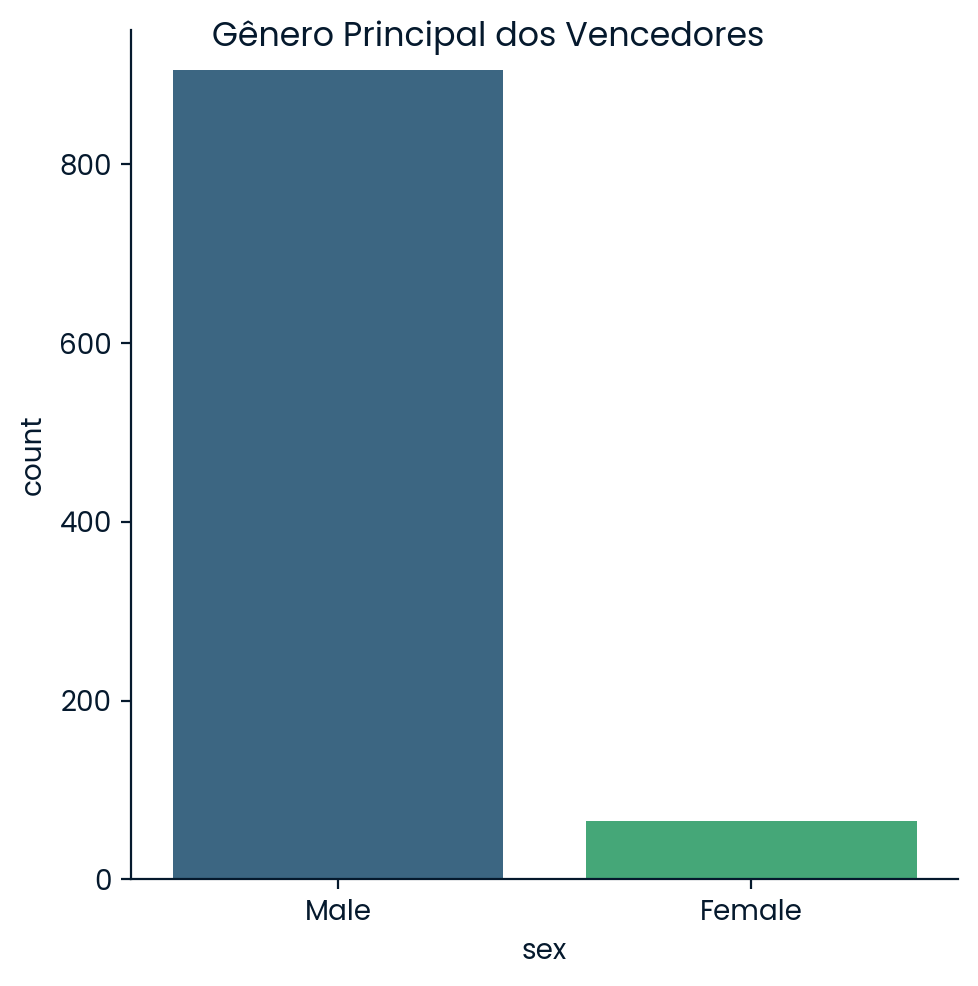

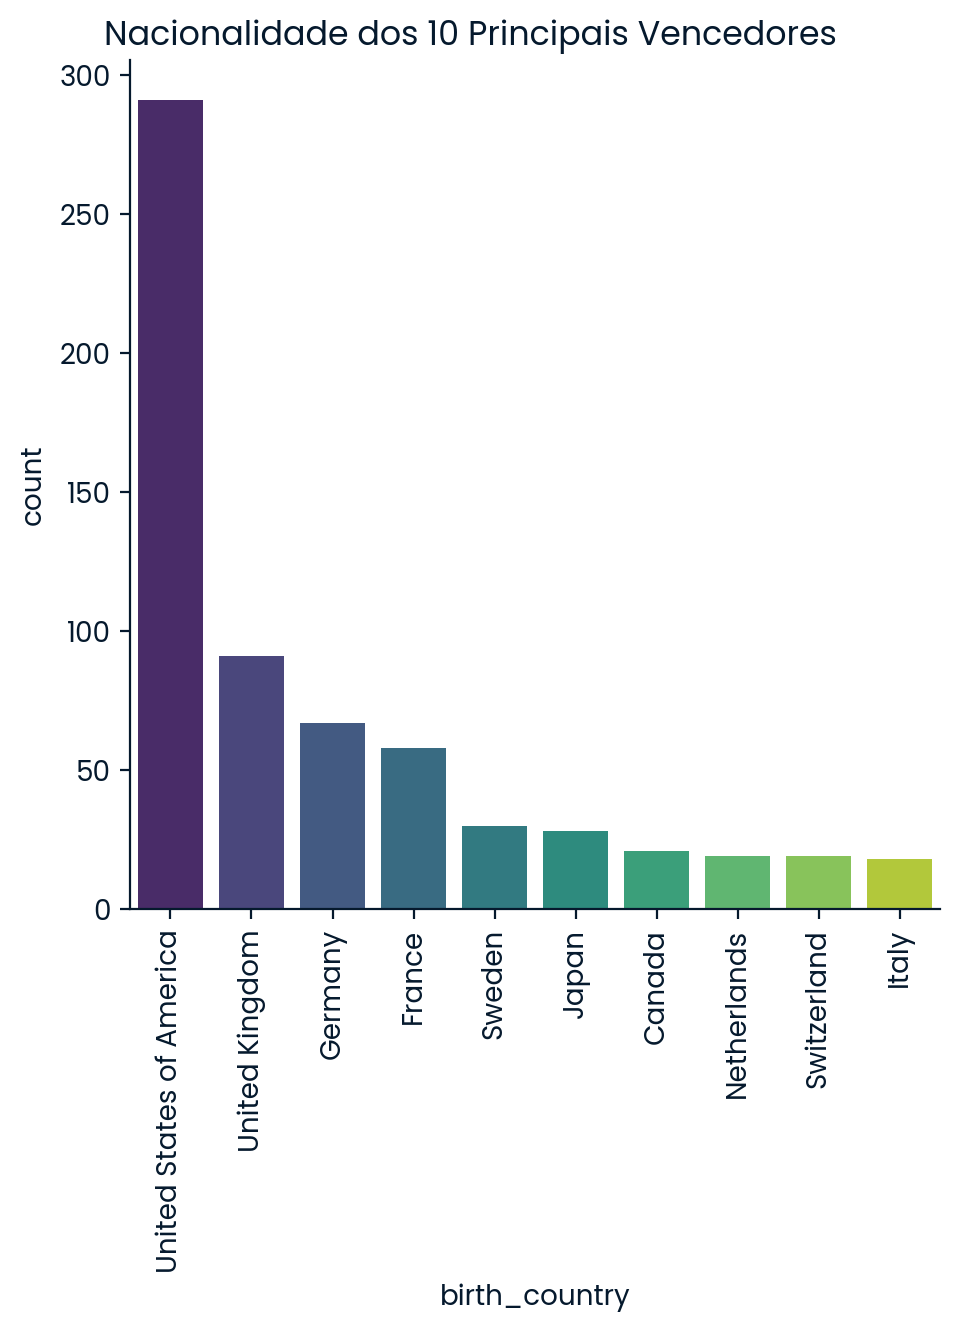

In [8]:
# Carregando as bibliotecas necessárias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Obtendo o DataFrame
nobel = pd.read_csv("./data/nobel.csv")

# Vendo a quantidade de vencedores do sexo feminino e masculino
nobel_gender_count = nobel.groupby("sex")["prize"].count()
top_gender = nobel_gender_count.sort_values(ascending=False).index[0]

# Vendo a quantidade de vencedores por país de nascimento
nobel_country_count = nobel.groupby("birth_country")["prize"].count()

# Obter os 10 principais países com mais vitórias
top_countries = nobel['birth_country'].value_counts().nlargest(10).index

top_country=top_countries[0]

# Criar um data frame apenas com os 10 principais países
nobel_top10 = nobel[nobel['birth_country'].isin(top_countries)]

# Mostrando o gênero principal dos vencedores do Prêmio Nobel
g = sns.catplot(x="sex", data=nobel, kind="count", palette='viridis', legend=False)
g.fig.suptitle("Gênero Principal dos Vencedores")

f = sns.catplot(x="birth_country", data=nobel_top10, kind="count", order=nobel_top10["birth_country"].value_counts().index, palette="viridis",legend=None)
f.fig.suptitle("Nacionalidade dos 10 Principais Vencedores",y=1.01)
plt.xticks(rotation=90)
plt.show()

# Explorando Dados ao longo dos anos
   ## Vendo qual década teve o maior número de vencedores nascidos nos EUA

Ano: 52, Vencedores: 2000


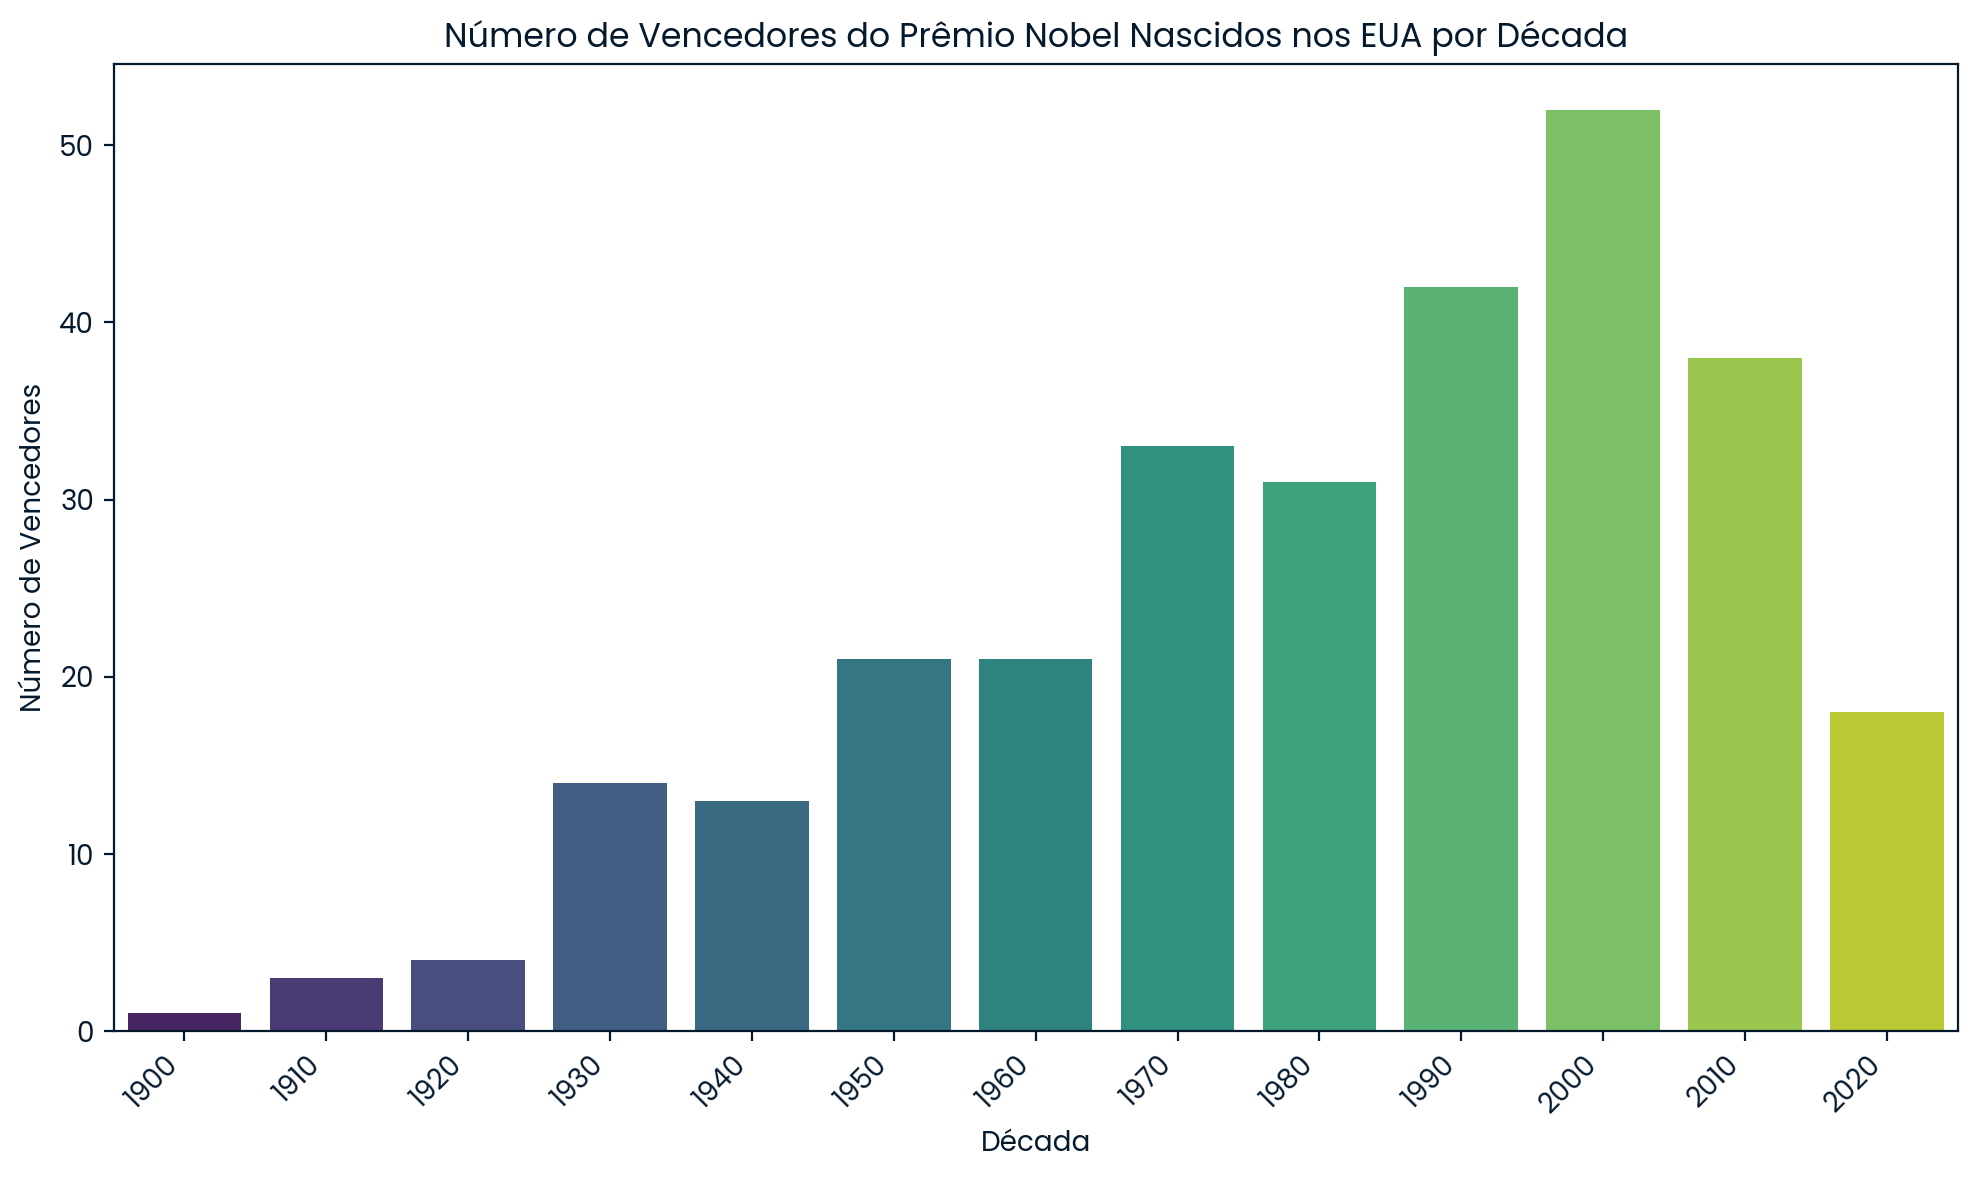

In [9]:
# Adicionando uma nova coluna para a década
nobel['decade'] = (nobel['year'] // 10) * 10

# Contando o número de vencedores por década
decade_counts = nobel.groupby('decade')['prize'].count()

# Contando o número de vencedores nascidos nos EUA por década
us_decade_counts = nobel[nobel['birth_country'] == 'United States of America'].groupby('decade')['prize'].count()

# Encontrando a década com o maior número de vencedores nascidos nos EUA
max_decade_usa = us_decade_counts.idxmax()
max_us_decade = us_decade_counts.max()

# Mostrando a década e o número de prêmios do ano com o maior número de vencedores nascidos nos EUA
print(f"Ano: {max_us_decade}, Vencedores: {max_decade_usa}")

plt.figure(figsize=(10, 6))  # Opcional: Ajustar o tamanho da figura
sns.barplot(x=us_decade_counts.index, y=us_decade_counts.values, palette='viridis')
plt.title("Número de Vencedores do Prêmio Nobel Nascidos nos EUA por Década")
plt.xlabel("Década")
plt.ylabel("Número de Vencedores")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Poder Feminino!
## Agora, vamos examinar a primeira mulher a ganhar o Prêmio Nobel e a categoria na qual ela o recebeu. Também exploraremos as categorias nas quais as mulheres ganharam Prêmios Nobel ao longo dos anos.

A primeira mulher a ganhar foi Marie Curie, née Sklodowska em 1903 na categoria: Physics
A década e a categoria com a maior proporção de vencedoras:
{2020: 'Literature'}


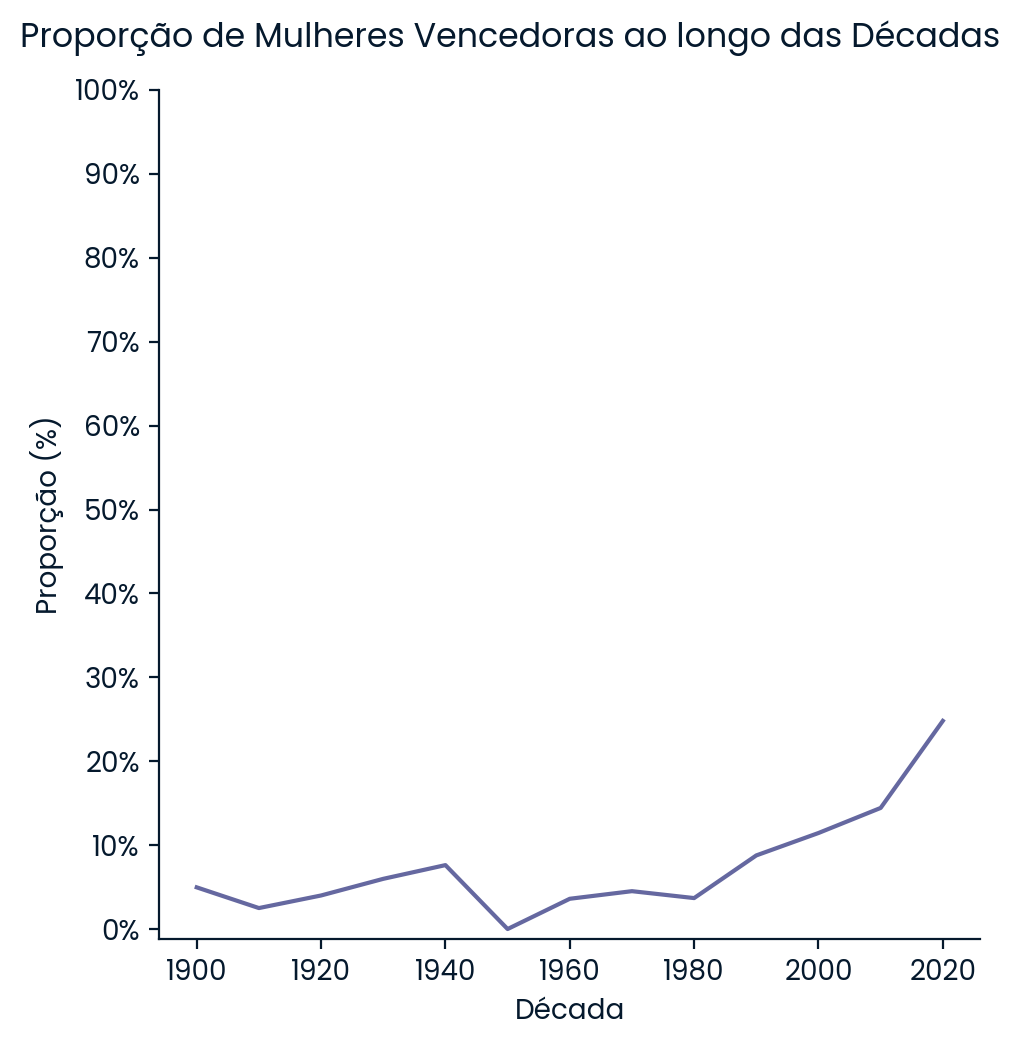

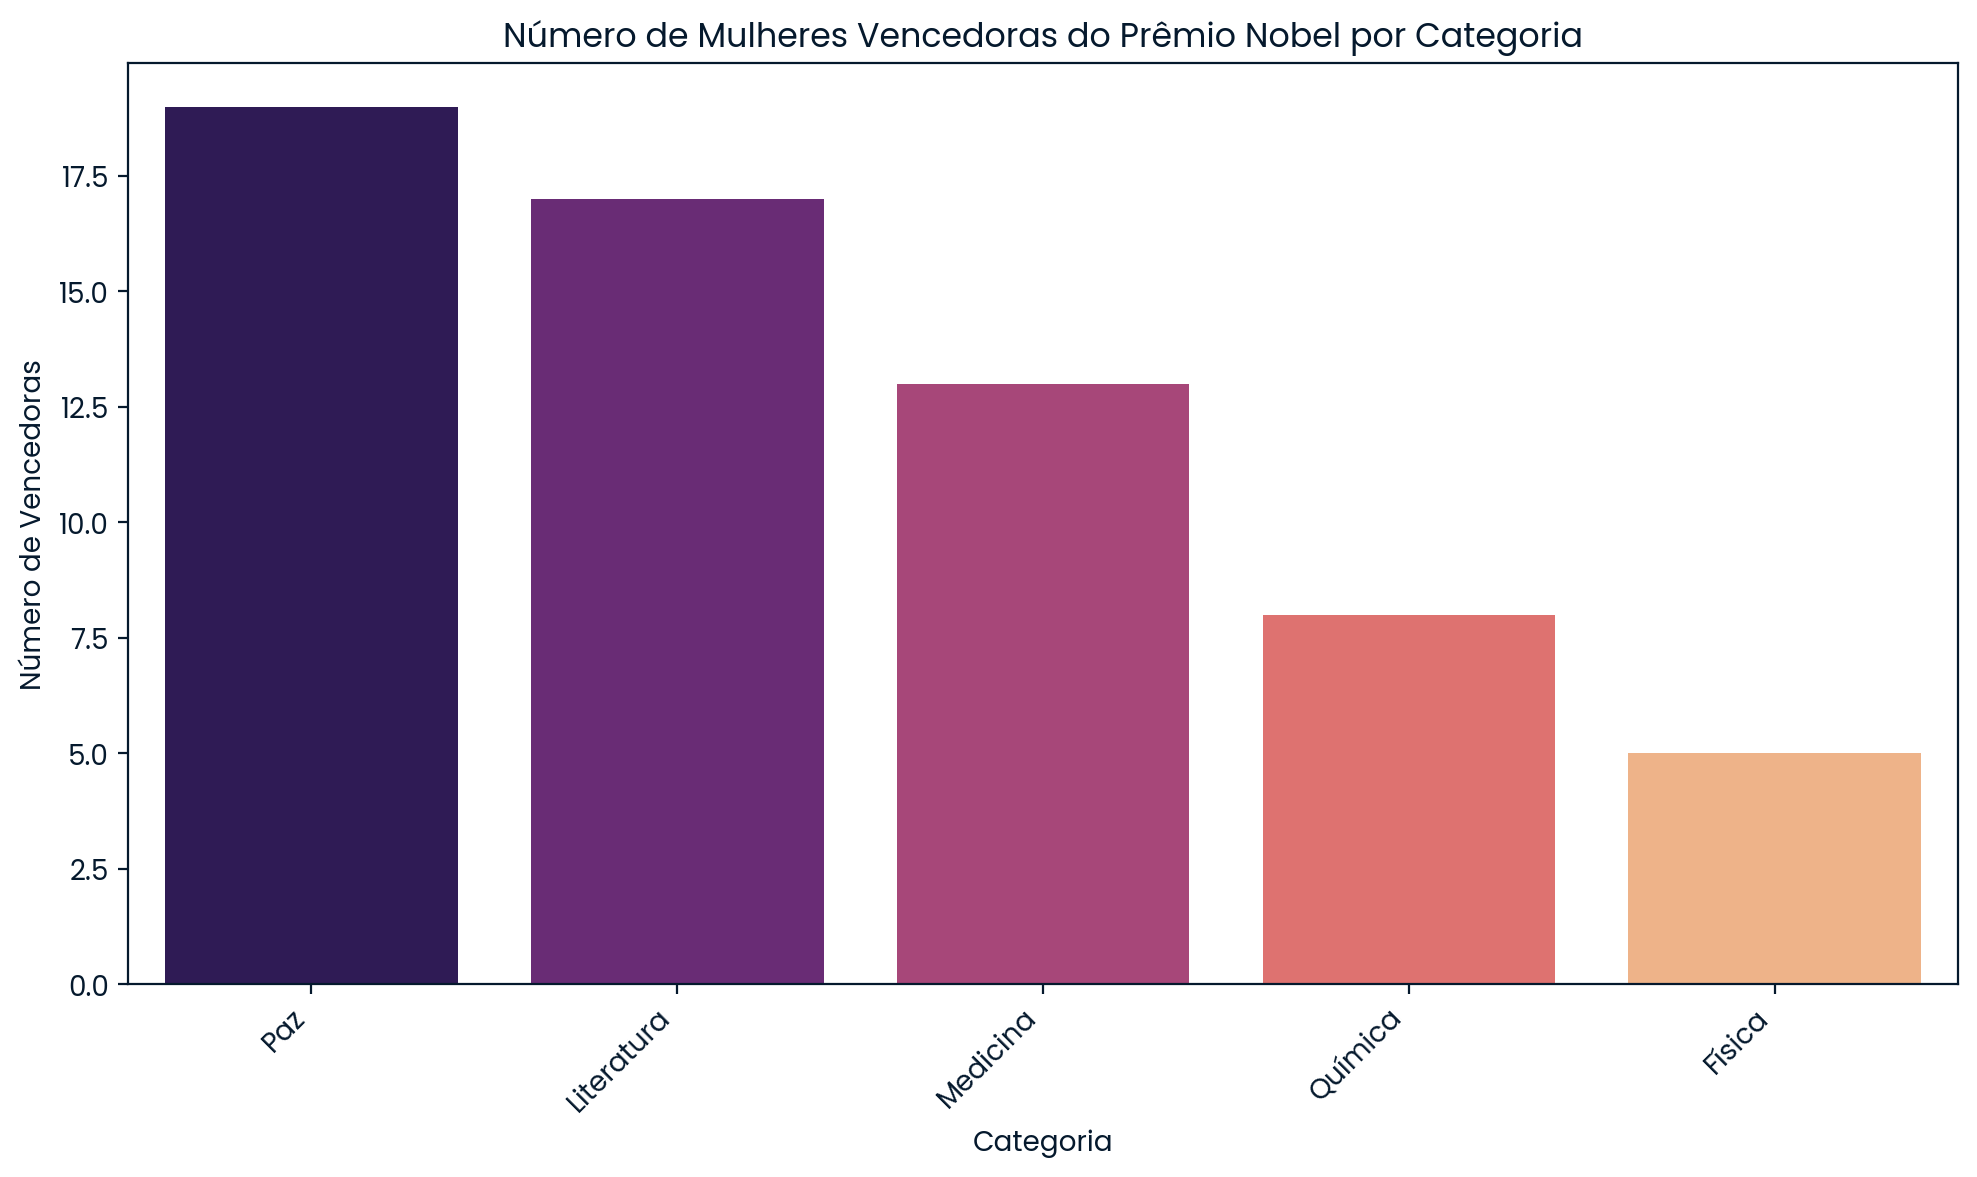

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# Encontrando a primeira mulher a ganhar o Prêmio Nobel e a categoria que ela ganhou
first_woman = nobel[nobel['sex'] == 'Female'].sort_values(by='year').iloc[0]

# Extraindo as informações sobre a primeira mulher a ganhar o prêmio Nobel
first_woman_name = first_woman['full_name']
first_woman_category = first_woman['category']
first_woman_year = first_woman['year']

# Exibindo as informações
first_woman_info = {
    'Name': first_woman_name,
    'Category': first_woman_category,
    'Year': first_woman_year
}
print(f"A primeira mulher a ganhar foi {first_woman_name} em {first_woman_year} na categoria: {first_woman_category}")

# Calcular o total de vencedores por ano e categoria
total_winners = nobel.groupby(['decade', 'category']).size().reset_index(name='total_winners')

# Calcular o número de vencedoras por ano e categoria
female_winners = nobel[nobel['sex'] == 'Female'].groupby(['decade', 'category']).size().reset_index(name='female_winners')

# Mesclar os dois DataFrames em 'year' e 'category'
merged = pd.merge(total_winners, female_winners, on=['decade', 'category'], how='left')

# Preencher valores NaN em 'female_winners' com 0 (caso não haja vencedoras em alguns grupos)
merged['female_winners'] = merged['female_winners'].fillna(0)

# Calcular a proporção de vencedoras
merged['proportion'] = merged['female_winners'] / merged['total_winners']

# Encontrar a linha com a maior proporção de vencedoras
max_proportion_row = merged.loc[merged['proportion'].idxmax()]

# Extrair a década e a categoria com a maior proporção
max_proportion_decade = max_proportion_row['decade']
max_proportion_category = max_proportion_row['category']

# Armazenar o resultado em um dicionário
max_female_dict = {
    max_proportion_decade: max_proportion_category 
}

# Exibir o resultado
print("A década e a categoria com a maior proporção de vencedoras:")
print(max_female_dict)

# Calcular o número de mulheres vencedoras do Prêmio Nobel por categoria
category_counts = nobel[nobel['sex'] == 'Female']['category'].value_counts()

# Dicionário de tradução das categorias
category_translation = {
    'Peace': 'Paz',
    'Literature': 'Literatura',
    'Chemistry': 'Química',
    'Physics': 'Física',
    'Medicine': 'Medicina',
    'Economic Sciences': 'Ciências Econômicas'
}

# Traduzir as categorias para o gráfico
translated_categories = category_counts.index.map(category_translation)

# Plotando a proporção de vencedoras ao longo das décadas
g = sns.relplot(x="decade", y="proportion", data=merged, kind="line", ci=None)
g.fig.suptitle("Proporção de Mulheres Vencedoras ao longo das Décadas", y=1.04)
g.set_axis_labels("Década", "Proporção (%)")
g.set(yticks=[i/100 for i in range(0, 101, 10)])
g.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x*100)}%'))

# Plotando o número de mulheres vencedoras do Prêmio Nobel por categoria
plt.figure(figsize=(10, 6))  # Opcional: Ajustar o tamanho da figura
sns.barplot(x=translated_categories, y=category_counts.values, palette='magma')
plt.title("Número de Mulheres Vencedoras do Prêmio Nobel por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Número de Vencedoras")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Me dê PAPAI!

## Vamos descobrir quem ganhou mais de um Prêmio Nobel. Você sabia que organizações também podem ganhar um Prêmio Nobel? Vamos olhar para elas também.

Lista de múltiplos vencedores
Marie Curie, née Sklodowska
Comité international de la Croix Rouge (International Committee of the Red Cross)
Linus Carl Pauling
Office of the United Nations High Commissioner for Refugees (UNHCR)
John Bardeen
Frederick Sanger


Text(0.5, 1.0, 'Vencedores Múltiplos do Prêmio Nobel')

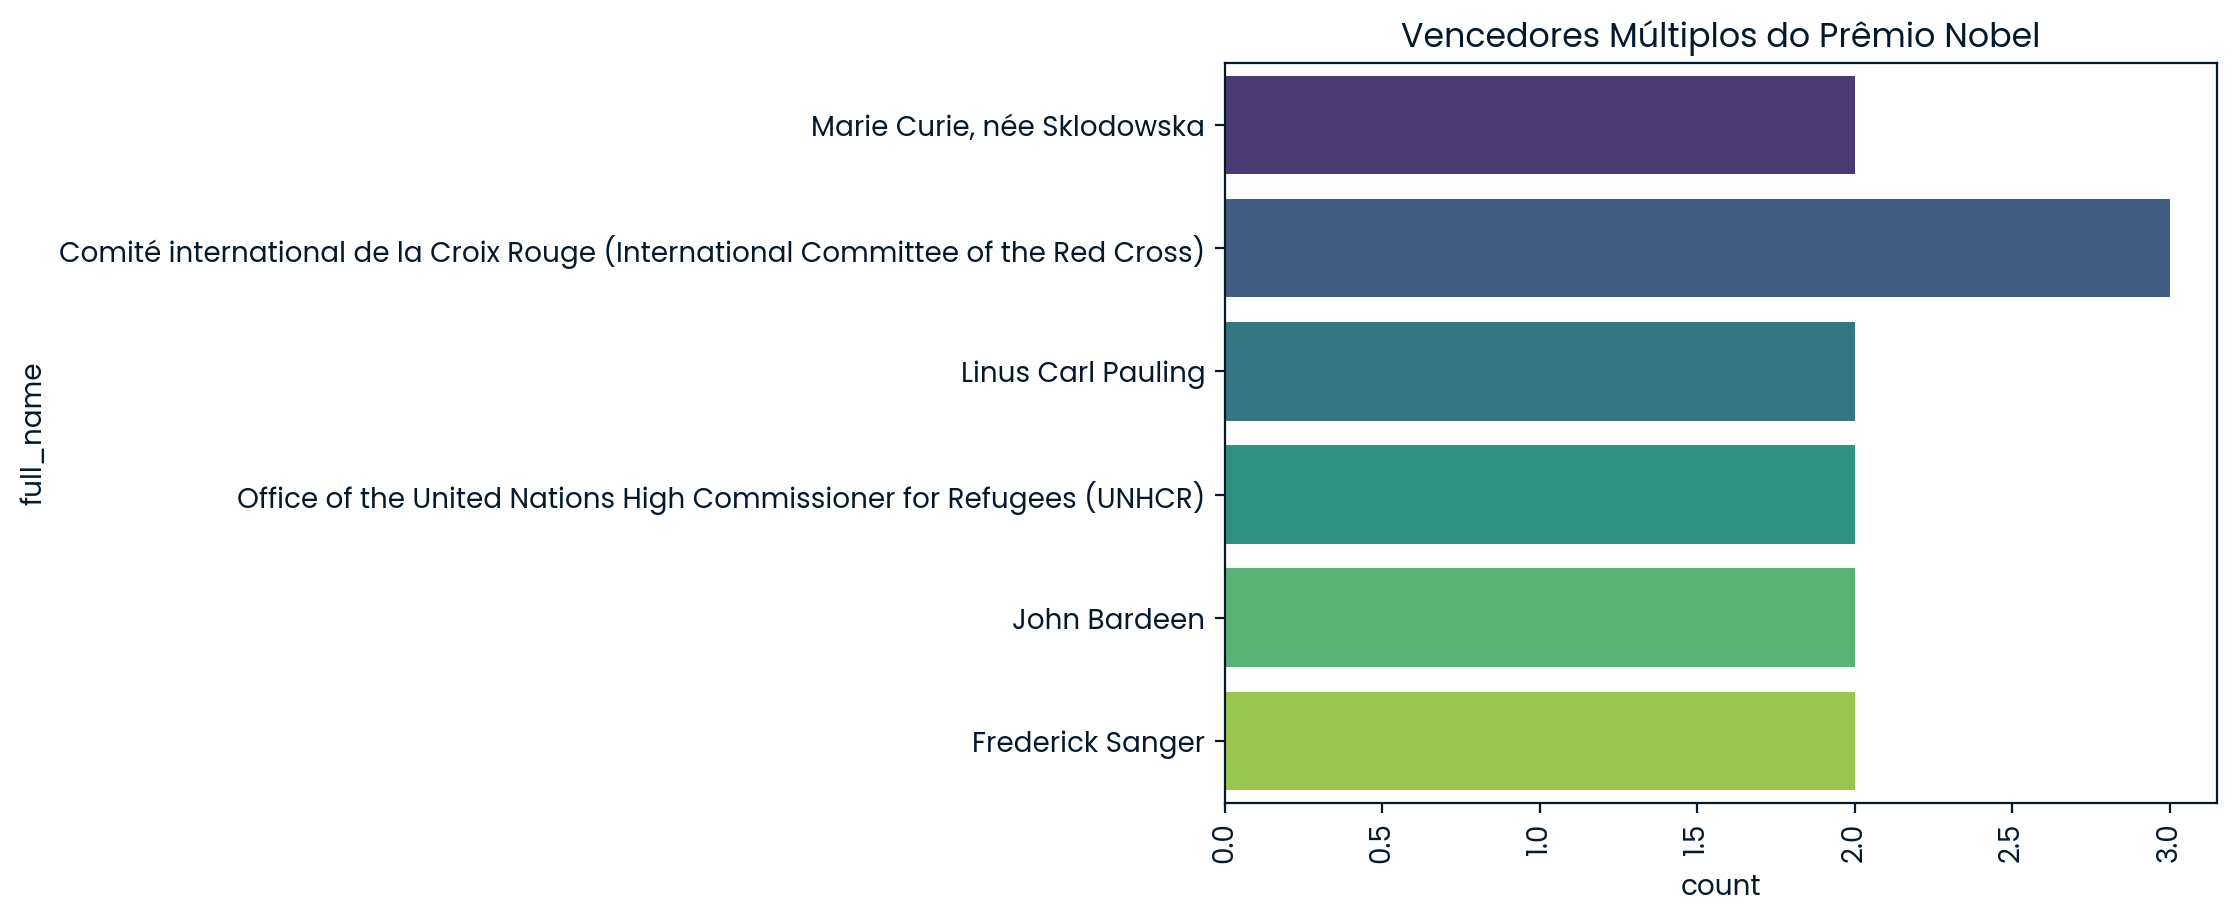

In [29]:
# filtrando o nome daqueles que ganharam mais de 1 Prêmio Nobel
multiple_winners = nobel.groupby("full_name").filter(lambda x: len(x) > 1)

# colocando na repeat list aqueles que ganharam mais de 1 Prêmio Nobel
repeat_list = []
for winner in  multiple_winners["full_name"].unique():
    repeat_list.append(winner)
print("Lista de múltiplos vencedores")
for winner in repeat_list:
    print(winner)

repeat_counts = multiple_winners["full_name"].value_counts()  
plt.xticks(rotation = 90)
g = sns.countplot(y='full_name',data=multiple_winners,palette='viridis')
g.set_title("Vencedores Múltiplos do Prêmio Nobel")